<a href="https://colab.research.google.com/github/ParhamPishro/Flavonoid/blob/main/5%20Modeling%20on%20Train%20Set/Optimal%20Dose%20and%20Time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_predict, cross_val_score

from sklearn.metrics import mean_absolute_error, r2_score, get_scorer_names, pairwise, confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay


Read Data

In [2]:
df = pd.read_excel("/content/FlavonoidData.xlsx")
df

,authors,flavonoid,cell line,time,dose,viability-mean,viability-error,viability-SD,viability-SE
0,Chen et al. 2017,Luteolin,KYSE30,48,10.0,77.272727,77.272727,0.001000,NaN
1,Chen et al. 2017,Luteolin,KYSE30,48,20.0,67.613636,67.613636,0.001000,NaN
2,Chen et al. 2017,Luteolin,KYSE30,48,40.0,47.159091,47.159091,0.001000,NaN
3,Chen et al. 2017,Luteolin,KYSE30,48,80.0,32.386364,32.386364,0.001000,NaN
4,Chen et al. 2017,Luteolin,KYSE30,72,10.0,69.886364,69.886364,0.001000,NaN
...,...,...,...,...,...,...,...,...,...
479,Zhu et al. 2016,Apigenin,KYSE150,24,20.0,88.407643,88.407643,0.001000,NaN
480,Zhu et al. 2016,Apigenin,KYSE150,24,40.0,78.980892,82.802548,3.821656,NaN
481,Zhu et al. 2016,Apigenin,KYSE150,24,60.0,67.261146,70.828025,3.566879,NaN
482,Zhu et al. 2016,Apigenin,KYSE150,24,80.0,45.350318,47.643312,2.292994,NaN


Discretized Data

In [3]:
df['v01'] = 1
df.loc[df['viability-mean']>50, 'v01'] = 0

In [4]:
df = df.drop(['authors', 'viability-error', 'viability-SD', 'viability-SE'], axis=1)
df

,flavonoid,cell line,time,dose,viability-mean,v01
0,Luteolin,KYSE30,48,10.0,77.272727,0
1,Luteolin,KYSE30,48,20.0,67.613636,0
2,Luteolin,KYSE30,48,40.0,47.159091,1
3,Luteolin,KYSE30,48,80.0,32.386364,1
4,Luteolin,KYSE30,72,10.0,69.886364,0
...,...,...,...,...,...,...
479,Apigenin,KYSE150,24,20.0,88.407643,0
480,Apigenin,KYSE150,24,40.0,78.980892,0
481,Apigenin,KYSE150,24,60.0,67.261146,0
482,Apigenin,KYSE150,24,80.0,45.350318,1


Encoding

In [5]:
df_encoded = pd.get_dummies(df, dtype=int)
df_encoded

,time,dose,viability-mean,v01,flavonoid_Acacetin,flavonoid_Apigenin,flavonoid_Chrysin,flavonoid_Galangin,flavonoid_Kaempferol,flavonoid_Luteolin,flavonoid_Myricetin,flavonoid_Quercetin,cell line_KYSE150,cell line_KYSE30,cell line_KYSE410,cell line_KYSE450,cell line_KYSE510,cell line_OE19,cell line_OE33,cell line_TE-1,cell line_TE-10,cell line_YES2
0,48,10.0,77.272727,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
1,48,20.0,67.613636,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
2,48,40.0,47.159091,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
3,48,80.0,32.386364,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
4,72,10.0,69.886364,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,24,20.0,88.407643,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
480,24,40.0,78.980892,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
481,24,60.0,67.261146,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
482,24,80.0,45.350318,1,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


In [6]:
X = df_encoded.drop(['viability-mean', 'v01'], axis=1)
y = df['viability-mean']
y01 = df['v01']

Initialize

In [9]:
#df_encoded
X_aca = df_encoded[:][df_encoded['flavonoid_Acacetin']==1].drop(['viability-mean', 'v01'], axis=1)
y01_aca = df_encoded[:][df_encoded['flavonoid_Acacetin']==1]['v01']

X_apg = df_encoded[:][df_encoded['flavonoid_Apigenin']==1].drop(['viability-mean', 'v01'], axis=1)
y01_apg = df_encoded[:][df_encoded['flavonoid_Apigenin']==1]['v01']

X_chr = df_encoded[:][df_encoded['flavonoid_Chrysin']==1].drop(['viability-mean', 'v01'], axis=1)
y01_chr = df_encoded[:][df_encoded['flavonoid_Chrysin']==1]['v01']

X_gal = df_encoded[:][df_encoded['flavonoid_Galangin']==1].drop(['viability-mean', 'v01'], axis=1)
y01_gal = df_encoded[:][df_encoded['flavonoid_Galangin']==1]['v01']

X_kae = df_encoded[:][df_encoded['flavonoid_Kaempferol']==1].drop(['viability-mean', 'v01'], axis=1)
y01_kae = df_encoded[:][df_encoded['flavonoid_Kaempferol']==1]['v01']

X_lut = df_encoded[:][df_encoded['flavonoid_Luteolin']==1].drop(['viability-mean', 'v01'], axis=1)
y01_lut = df_encoded[:][df_encoded['flavonoid_Luteolin']==1]['v01']

X_myr = df_encoded[:][df_encoded['flavonoid_Myricetin']==1].drop(['viability-mean', 'v01'], axis=1)
y01_myr = df_encoded[:][df_encoded['flavonoid_Myricetin']==1]['v01']

X_que = df_encoded[:][df_encoded['flavonoid_Quercetin']==1].drop(['viability-mean', 'v01'], axis=1)
y01_que = df_encoded[:][df_encoded['flavonoid_Quercetin']==1]['v01']

dtc = DecisionTreeClassifier(criterion='gini', max_depth=14, min_samples_leaf=1, min_samples_split=2, random_state=2, splitter='best')

fit & validation

In [10]:
dtc.fit(X_aca, y01_aca)
dtc_aca = dtc.predict(X_aca)
dtc.fit(X_apg, y01_apg)
dtc_apg = dtc.predict(X_apg)
dtc.fit(X_chr, y01_chr)
dtc_chr = dtc.predict(X_chr)
dtc.fit(X_gal, y01_gal)
dtc_gal = dtc.predict(X_gal)
dtc.fit(X_kae, y01_kae)
dtc_kae = dtc.predict(X_kae)
dtc.fit(X_lut, y01_lut)
dtc_lut = dtc.predict(X_lut)
dtc.fit(X_myr, y01_myr)
dtc_myr = dtc.predict(X_myr)
dtc.fit(X_que, y01_que)
dtc_que = dtc.predict(X_que)

In [11]:
print("aca (Train): ", accuracy_score(y01_aca, dtc_aca))
print("apg (Train): ", accuracy_score(y01_apg, dtc_apg))
print("chr (Train): ", accuracy_score(y01_chr, dtc_chr))
print("gal (Train): ", accuracy_score(y01_gal, dtc_gal))
print("kae (Train): ", accuracy_score(y01_kae, dtc_kae))
print("lut (Train): ", accuracy_score(y01_lut, dtc_lut))
print("myr (Train): ", accuracy_score(y01_myr, dtc_myr))
print("que (Train): ", accuracy_score(y01_que, dtc_que))

aca (Train):  1.0
apg (Train):  1.0
chr (Train):  0.9782608695652174
gal (Train):  1.0
kae (Train):  0.96
lut (Train):  1.0
myr (Train):  1.0
que (Train):  1.0


Find Optimal Dose and Time for each Flavonoid

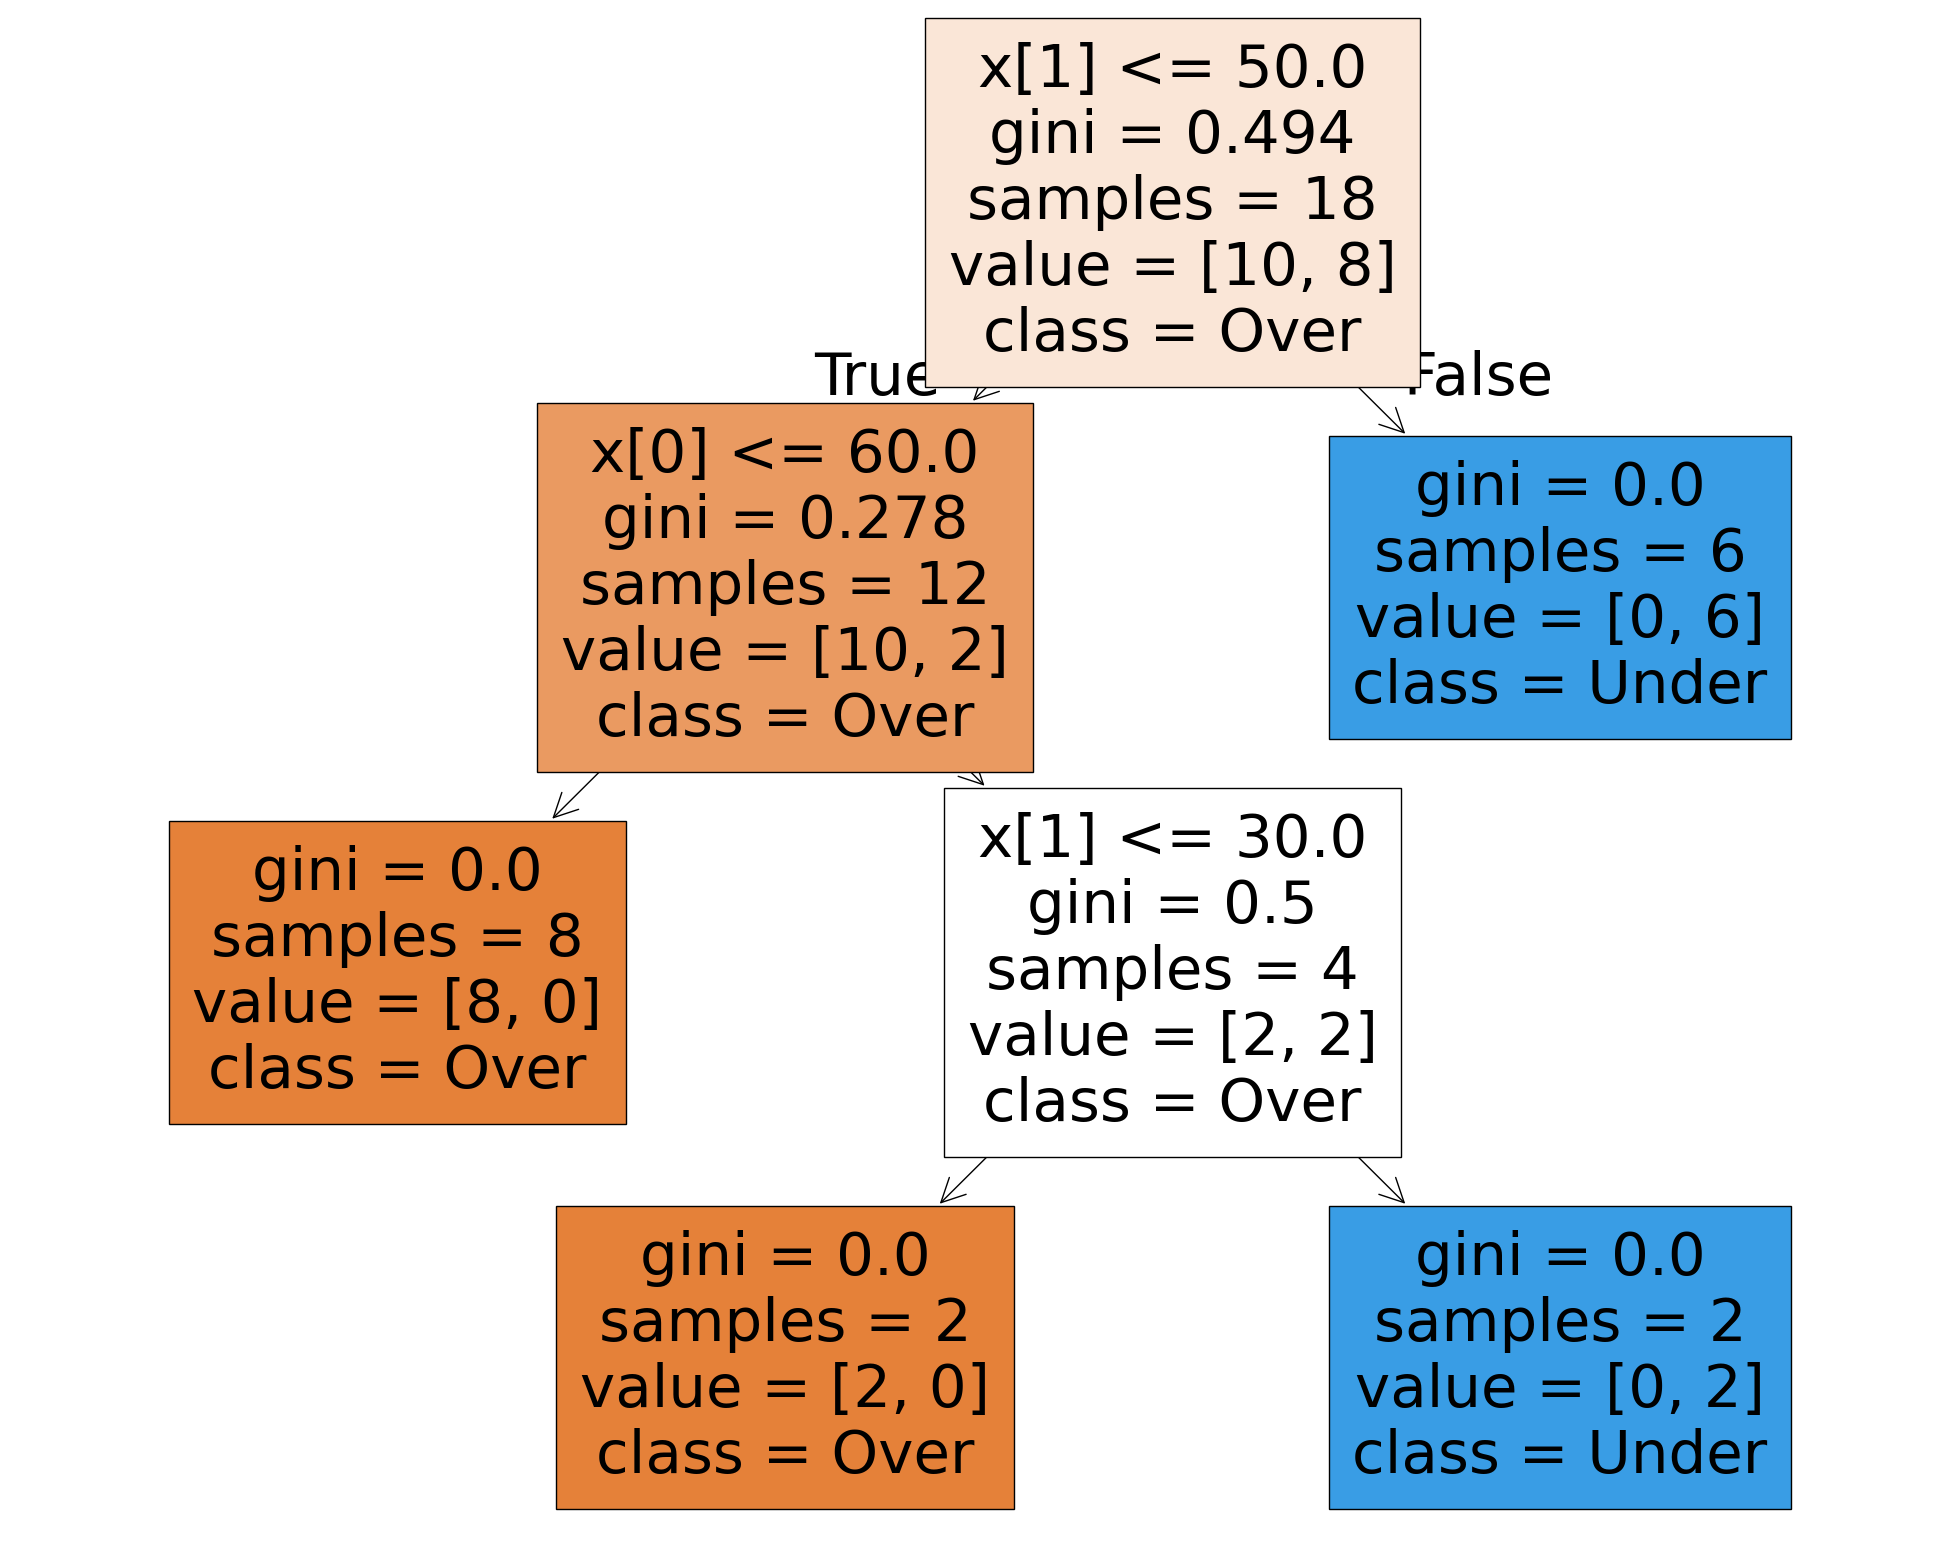

In [16]:
dtc = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_leaf=1, min_samples_split=2, random_state=2, splitter='best')
dtc.fit(X_aca, y01_aca)

fig = plt.figure(figsize=(25,20))
_ = plot_tree(dtc, class_names=['Over', 'Under'], filled=True)

[Text(0.6, 0.9166666666666666, 'x[1] <= 77.5\ngini = 0.386\nsamples = 69\nvalue = [51, 18]\nclass = Over'),
 Text(0.3333333333333333, 0.75, 'x[11] <= 0.5\ngini = 0.241\nsamples = 50\nvalue = [43.0, 7.0]\nclass = Over'),
 Text(0.4666666666666667, 0.8333333333333333, 'True  '),
 Text(0.2, 0.5833333333333334, 'x[1] <= 35.0\ngini = 0.19\nsamples = 47\nvalue = [42, 5]\nclass = Over'),
 Text(0.13333333333333333, 0.4166666666666667, 'gini = 0.0\nsamples = 27\nvalue = [27, 0]\nclass = Over'),
 Text(0.26666666666666666, 0.4166666666666667, 'x[14] <= 0.5\ngini = 0.375\nsamples = 20\nvalue = [15, 5]\nclass = Over'),
 Text(0.13333333333333333, 0.25, 'x[1] <= 67.5\ngini = 0.133\nsamples = 14\nvalue = [13, 1]\nclass = Over'),
 Text(0.06666666666666667, 0.08333333333333333, 'gini = 0.0\nsamples = 11\nvalue = [11, 0]\nclass = Over'),
 Text(0.2, 0.08333333333333333, 'gini = 0.444\nsamples = 3\nvalue = [2, 1]\nclass = Over'),
 Text(0.4, 0.25, 'x[0] <= 36.0\ngini = 0.444\nsamples = 6\nvalue = [2, 4]\ncla

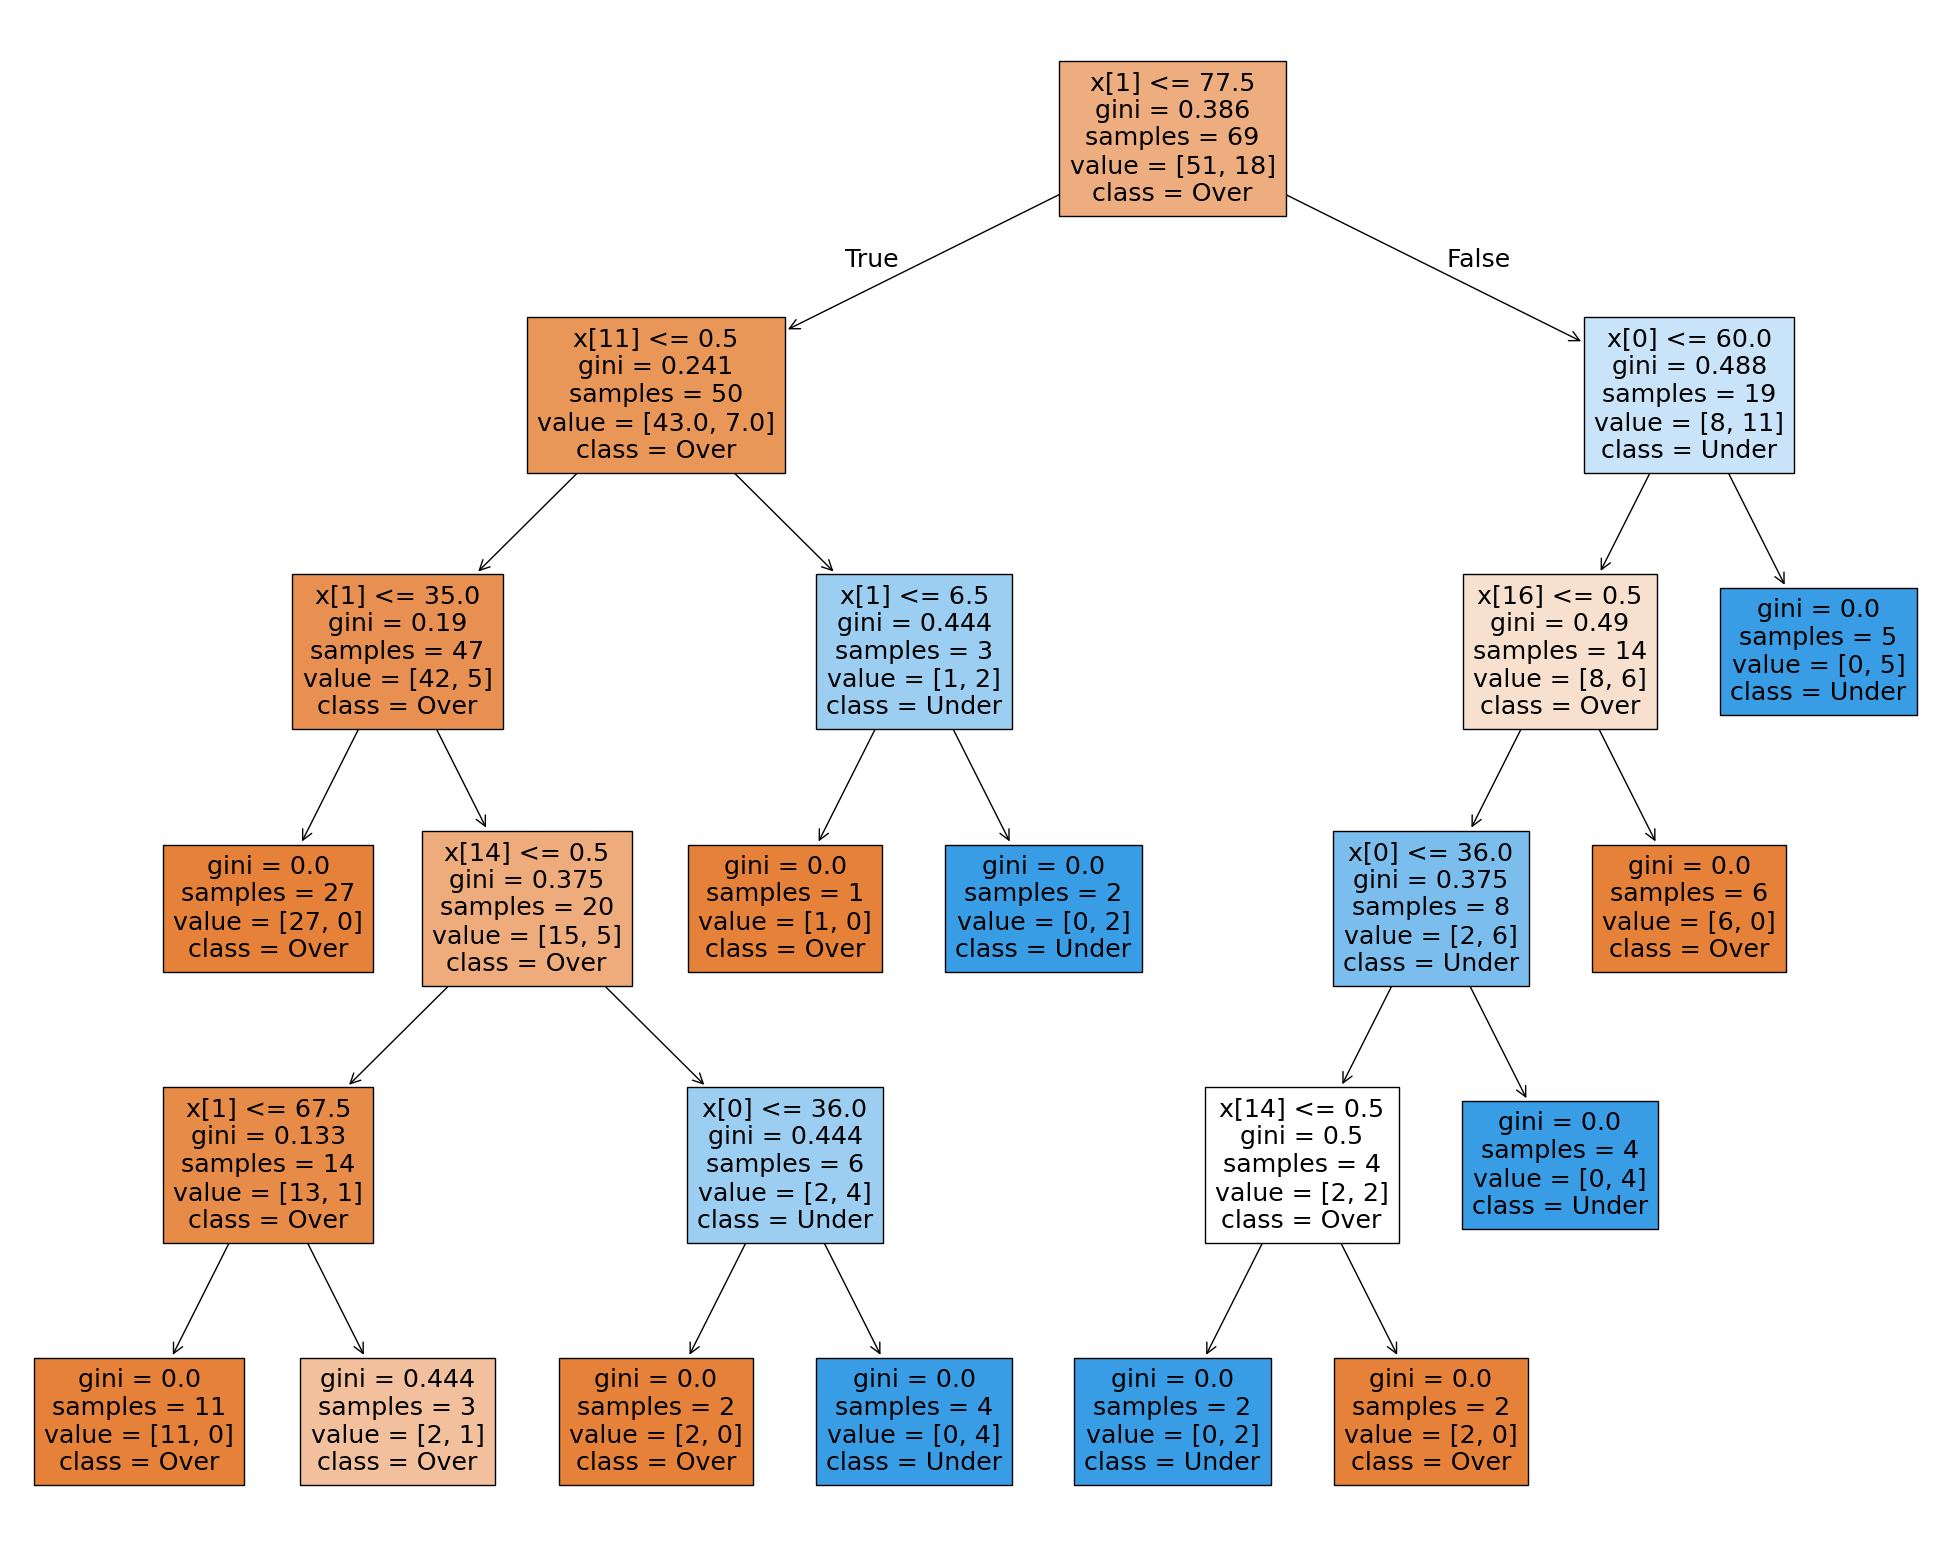

In [17]:
dtc = DecisionTreeClassifier(criterion='gini', max_depth=5, min_samples_leaf=1, min_samples_split=2, random_state=2, splitter='best')
dtc.fit(X_apg, y01_apg)

fig = plt.figure(figsize=(25,20))
plot_tree(dtc, class_names=['Over', 'Under'], filled=True)

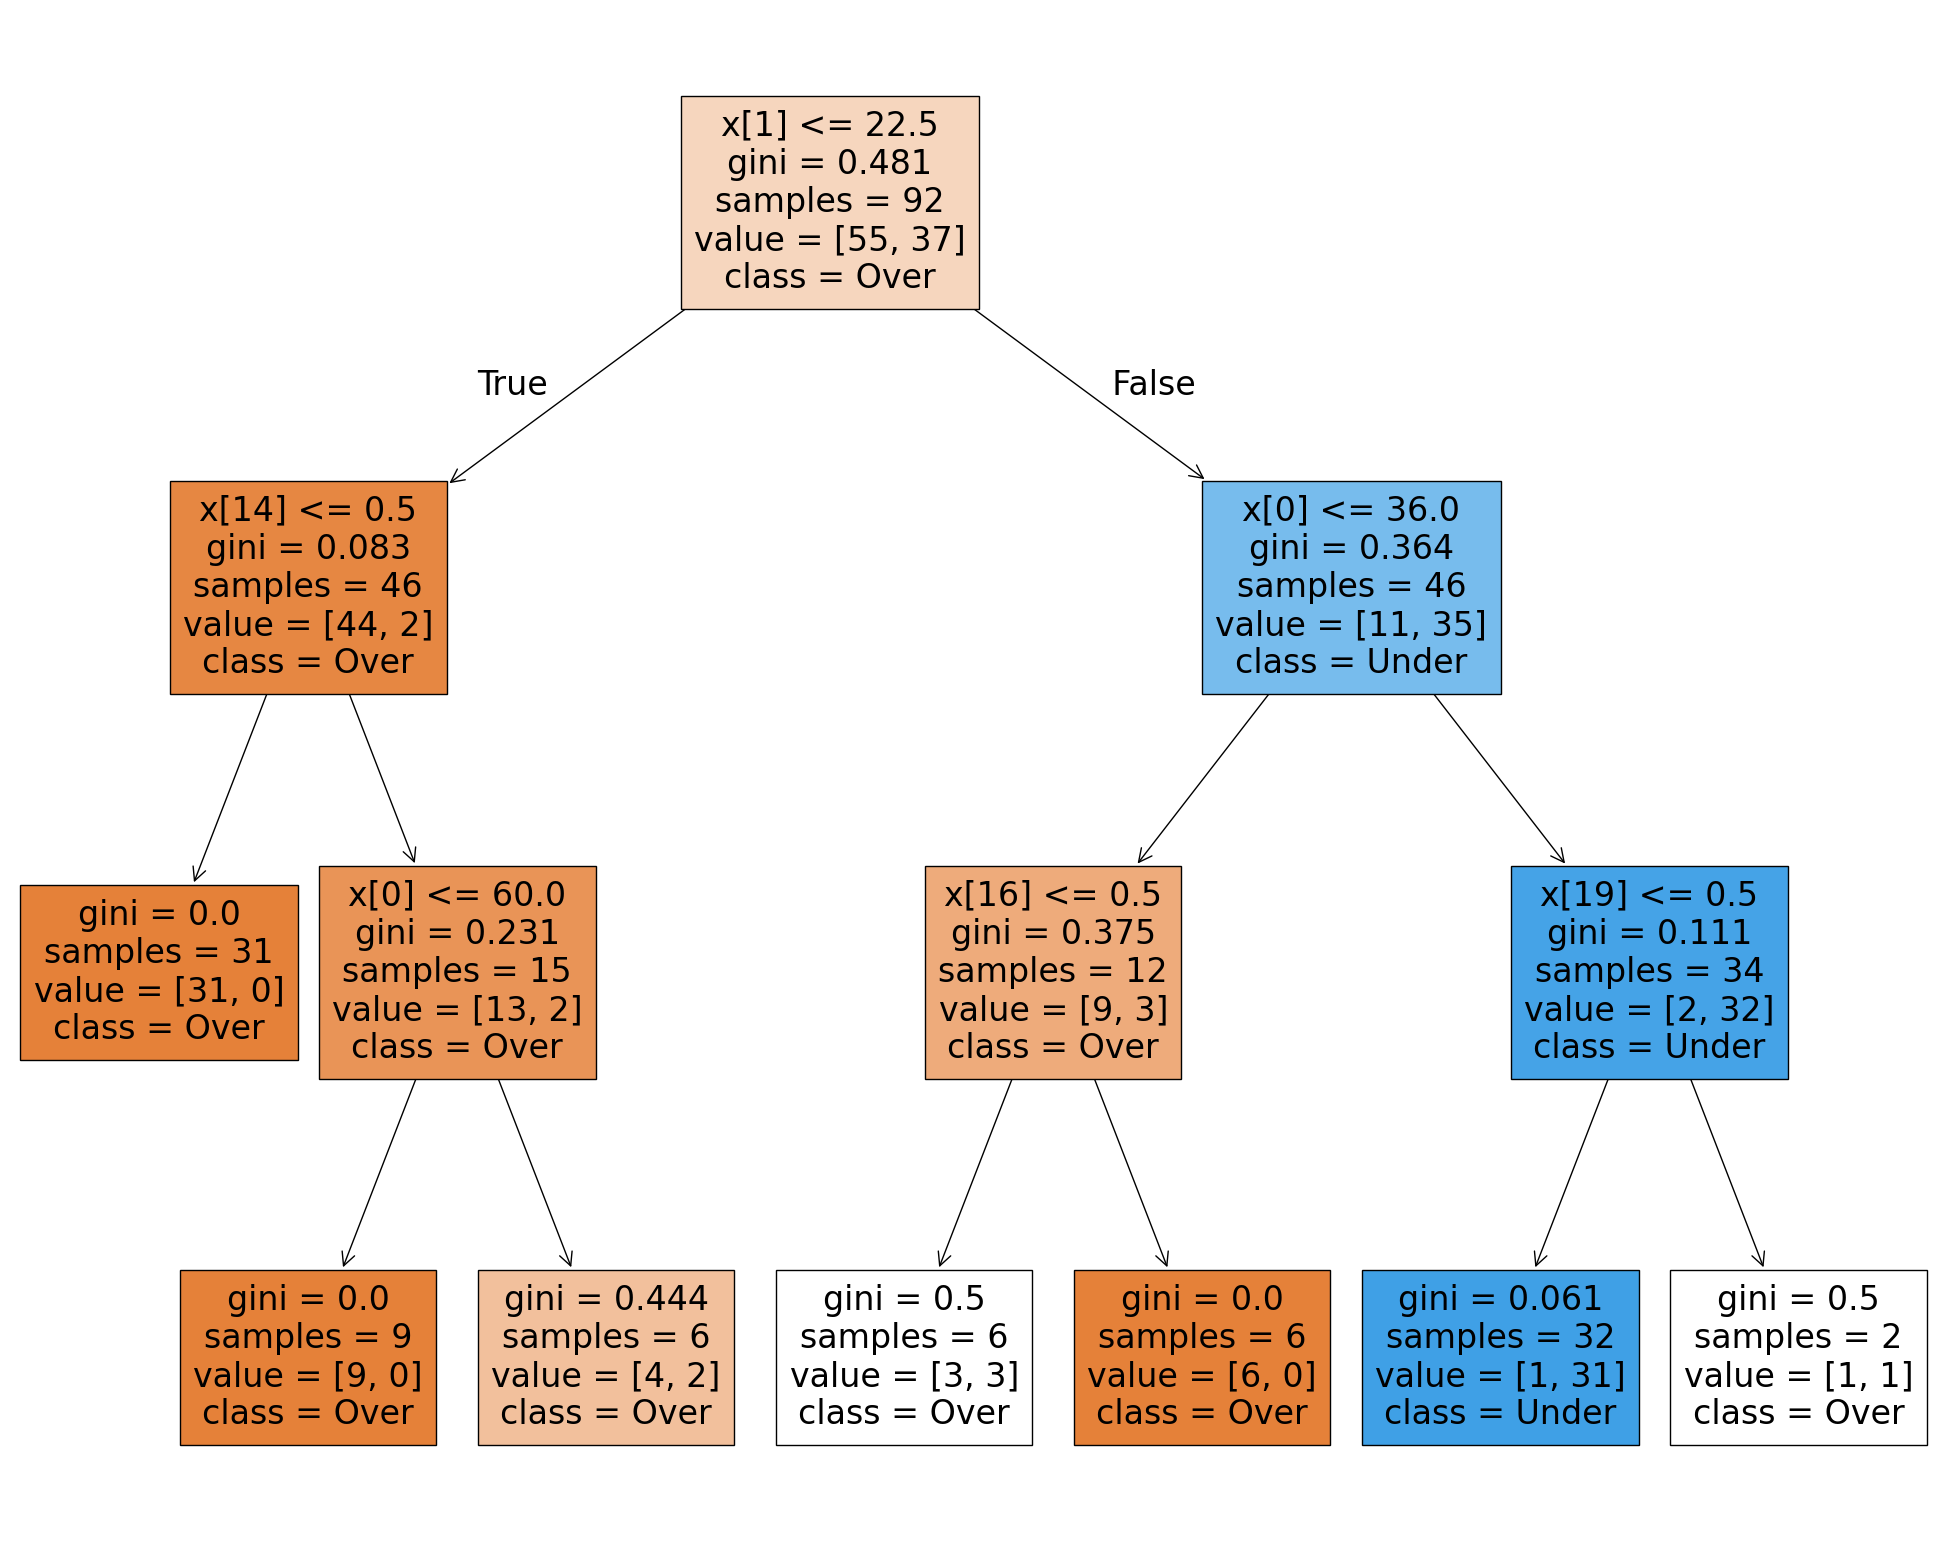

In [18]:
dtc = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_leaf=1, min_samples_split=2, random_state=2, splitter='best')
dtc.fit(X_chr, y01_chr)

fig = plt.figure(figsize=(25,20))
_ = plot_tree(dtc, class_names=['Over', 'Under'], filled=True)

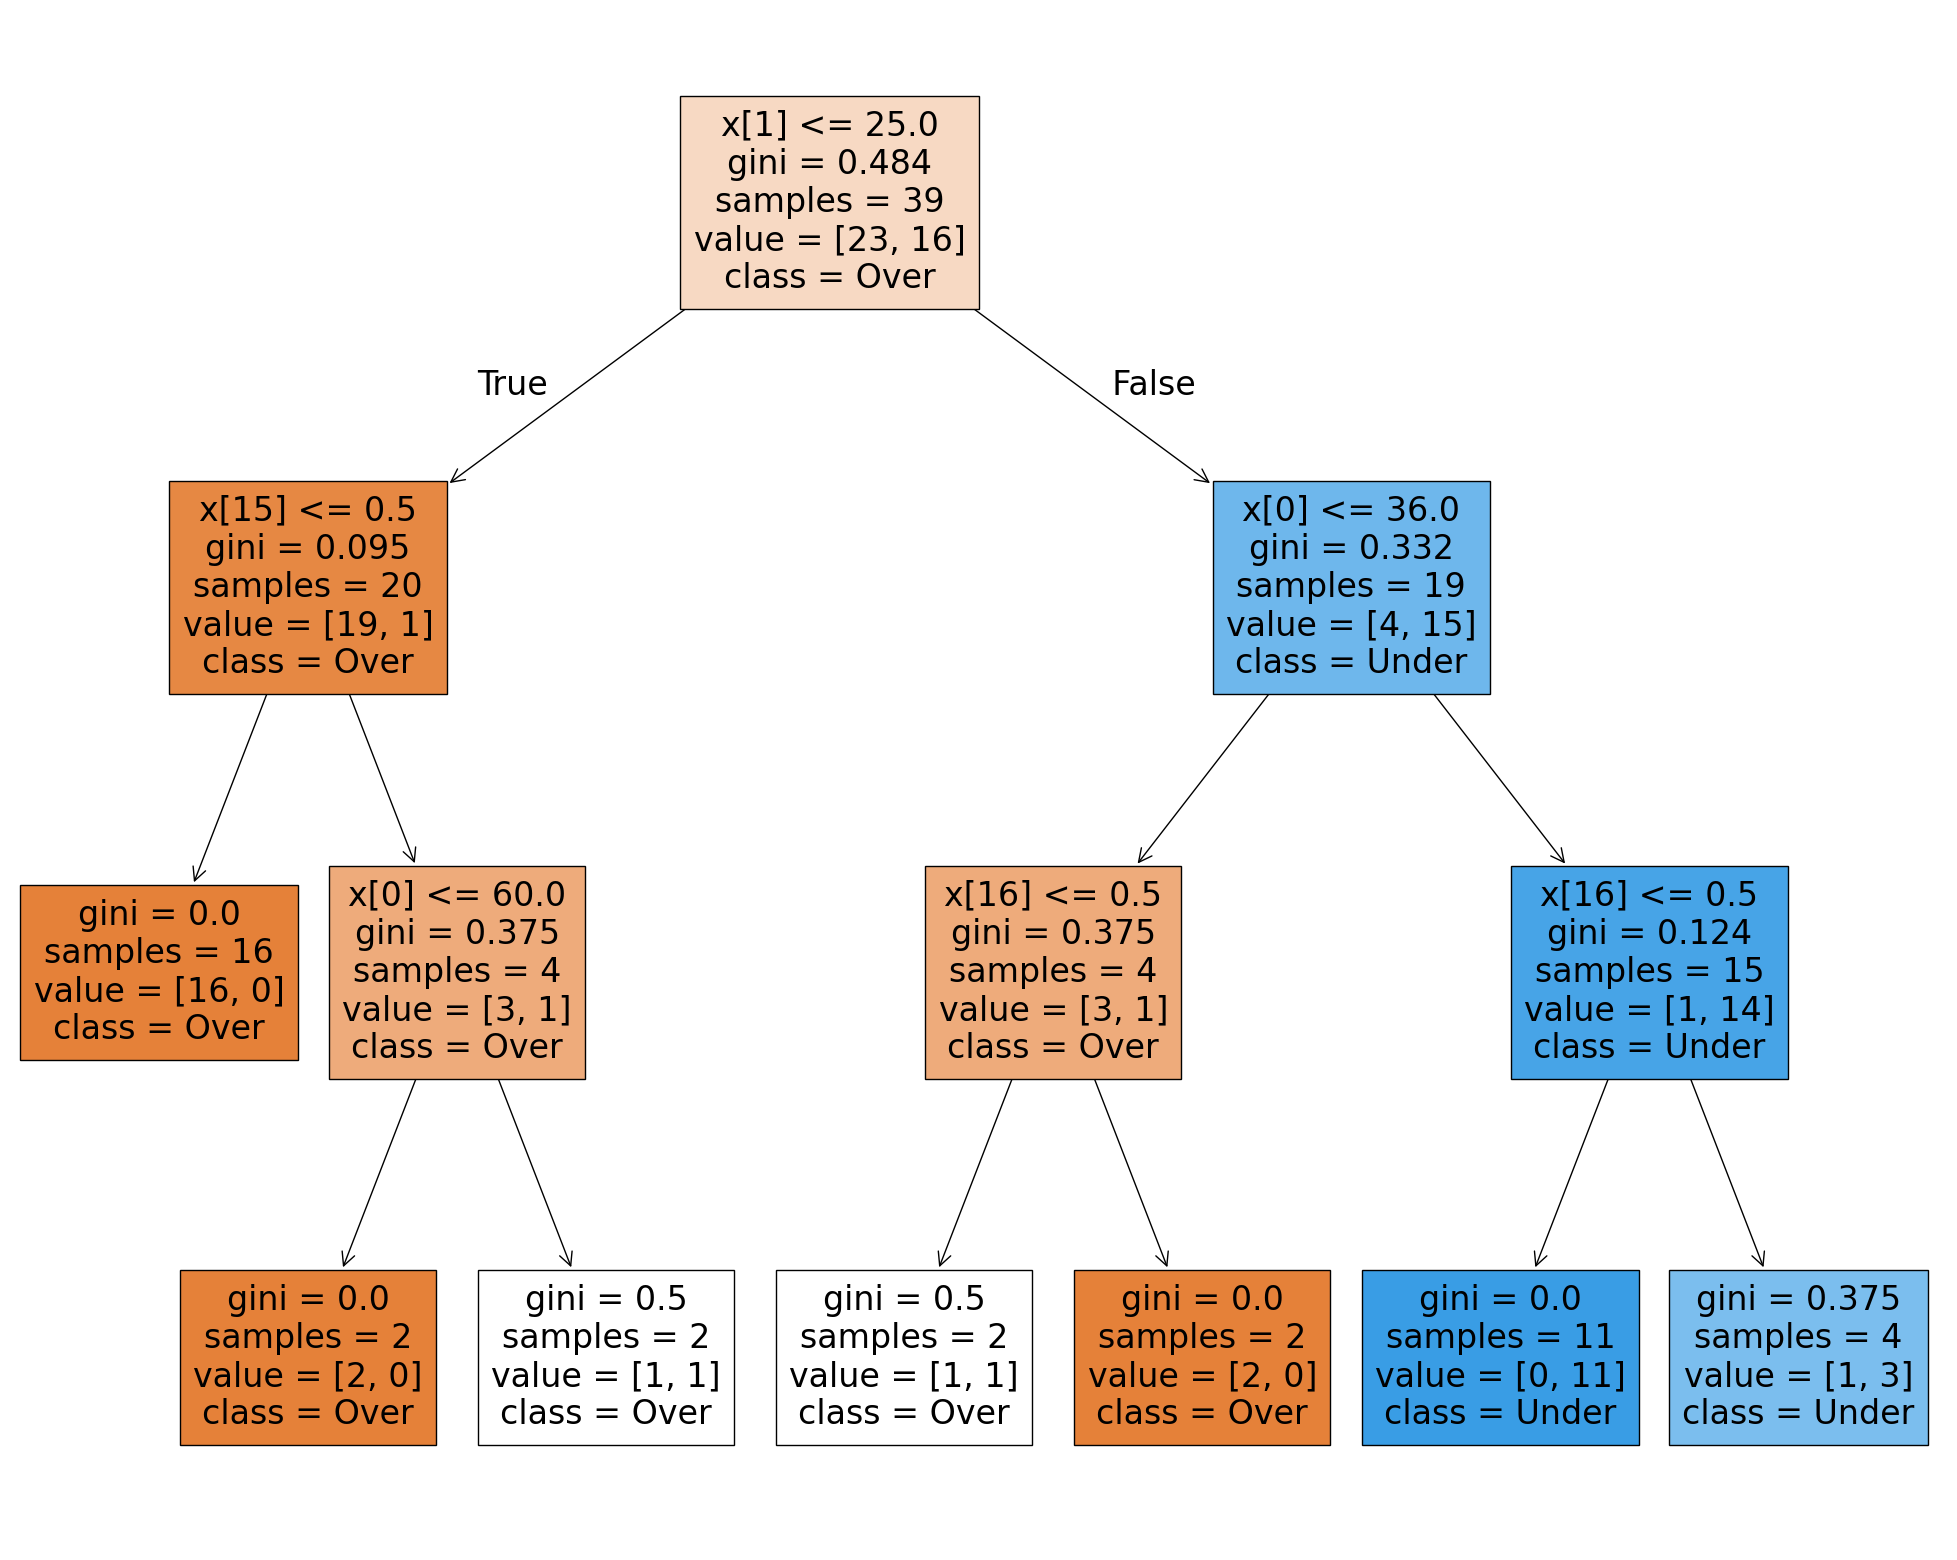

In [19]:
dtc = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_leaf=1, min_samples_split=2, random_state=2, splitter='best')
dtc.fit(X_gal, y01_gal)

fig = plt.figure(figsize=(25,20))
_ = plot_tree(dtc, class_names=['Over', 'Under'], filled=True)

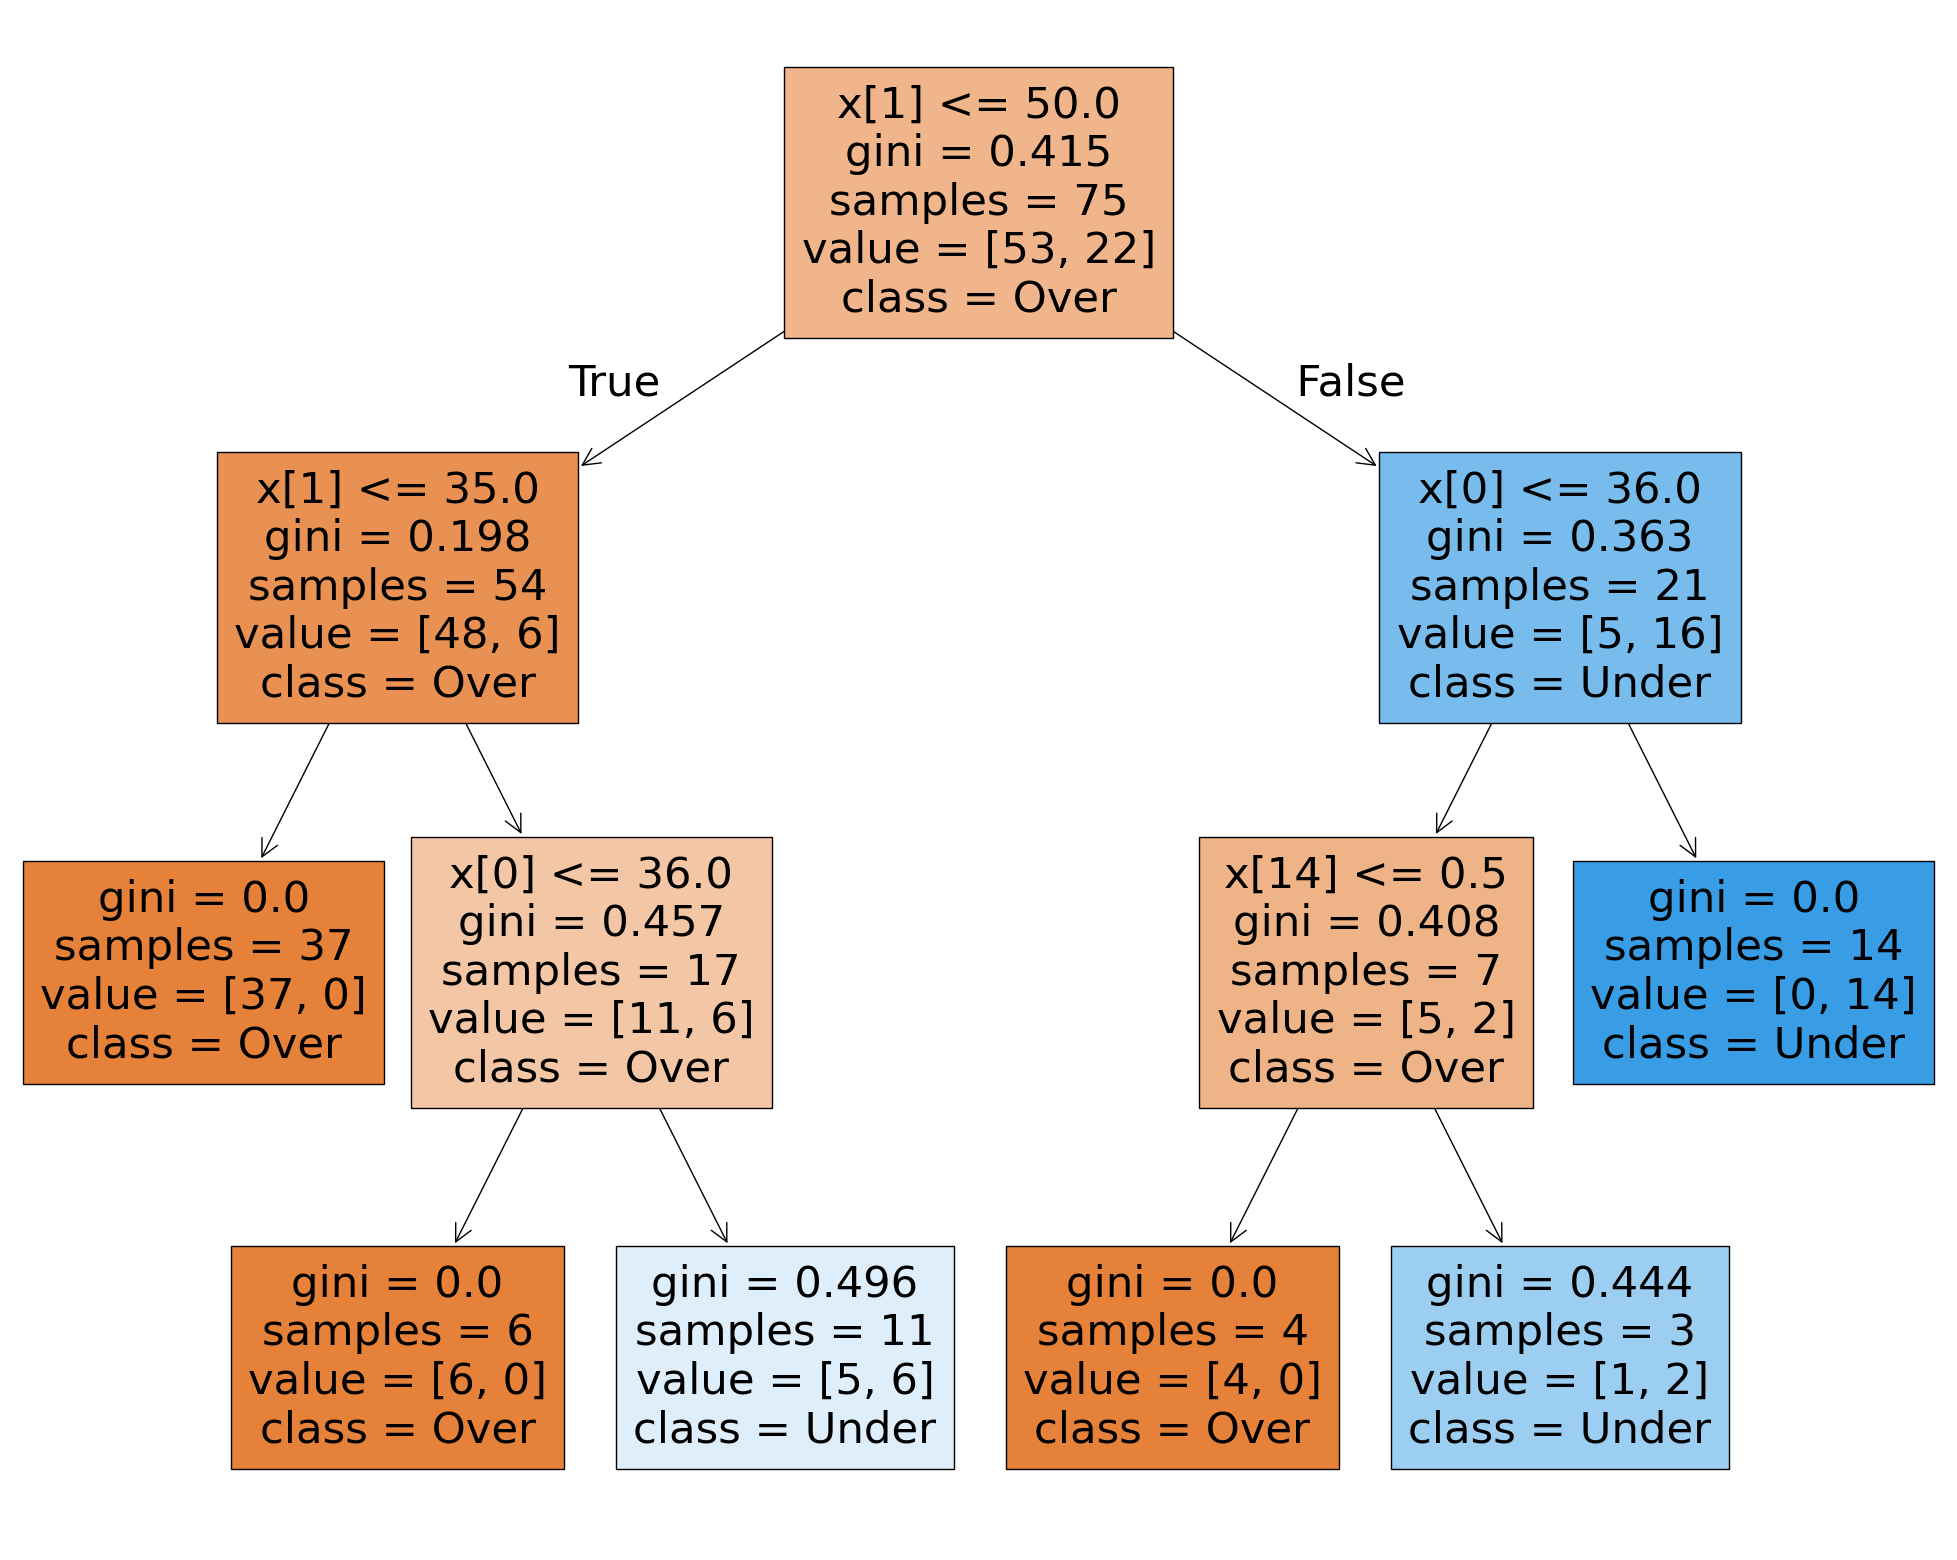

In [20]:
dtc = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_leaf=1, min_samples_split=2, random_state=2, splitter='best')
dtc.fit(X_kae, y01_kae)

fig = plt.figure(figsize=(25,20))
_ = plot_tree(dtc, class_names=['Over', 'Under'], filled=True)

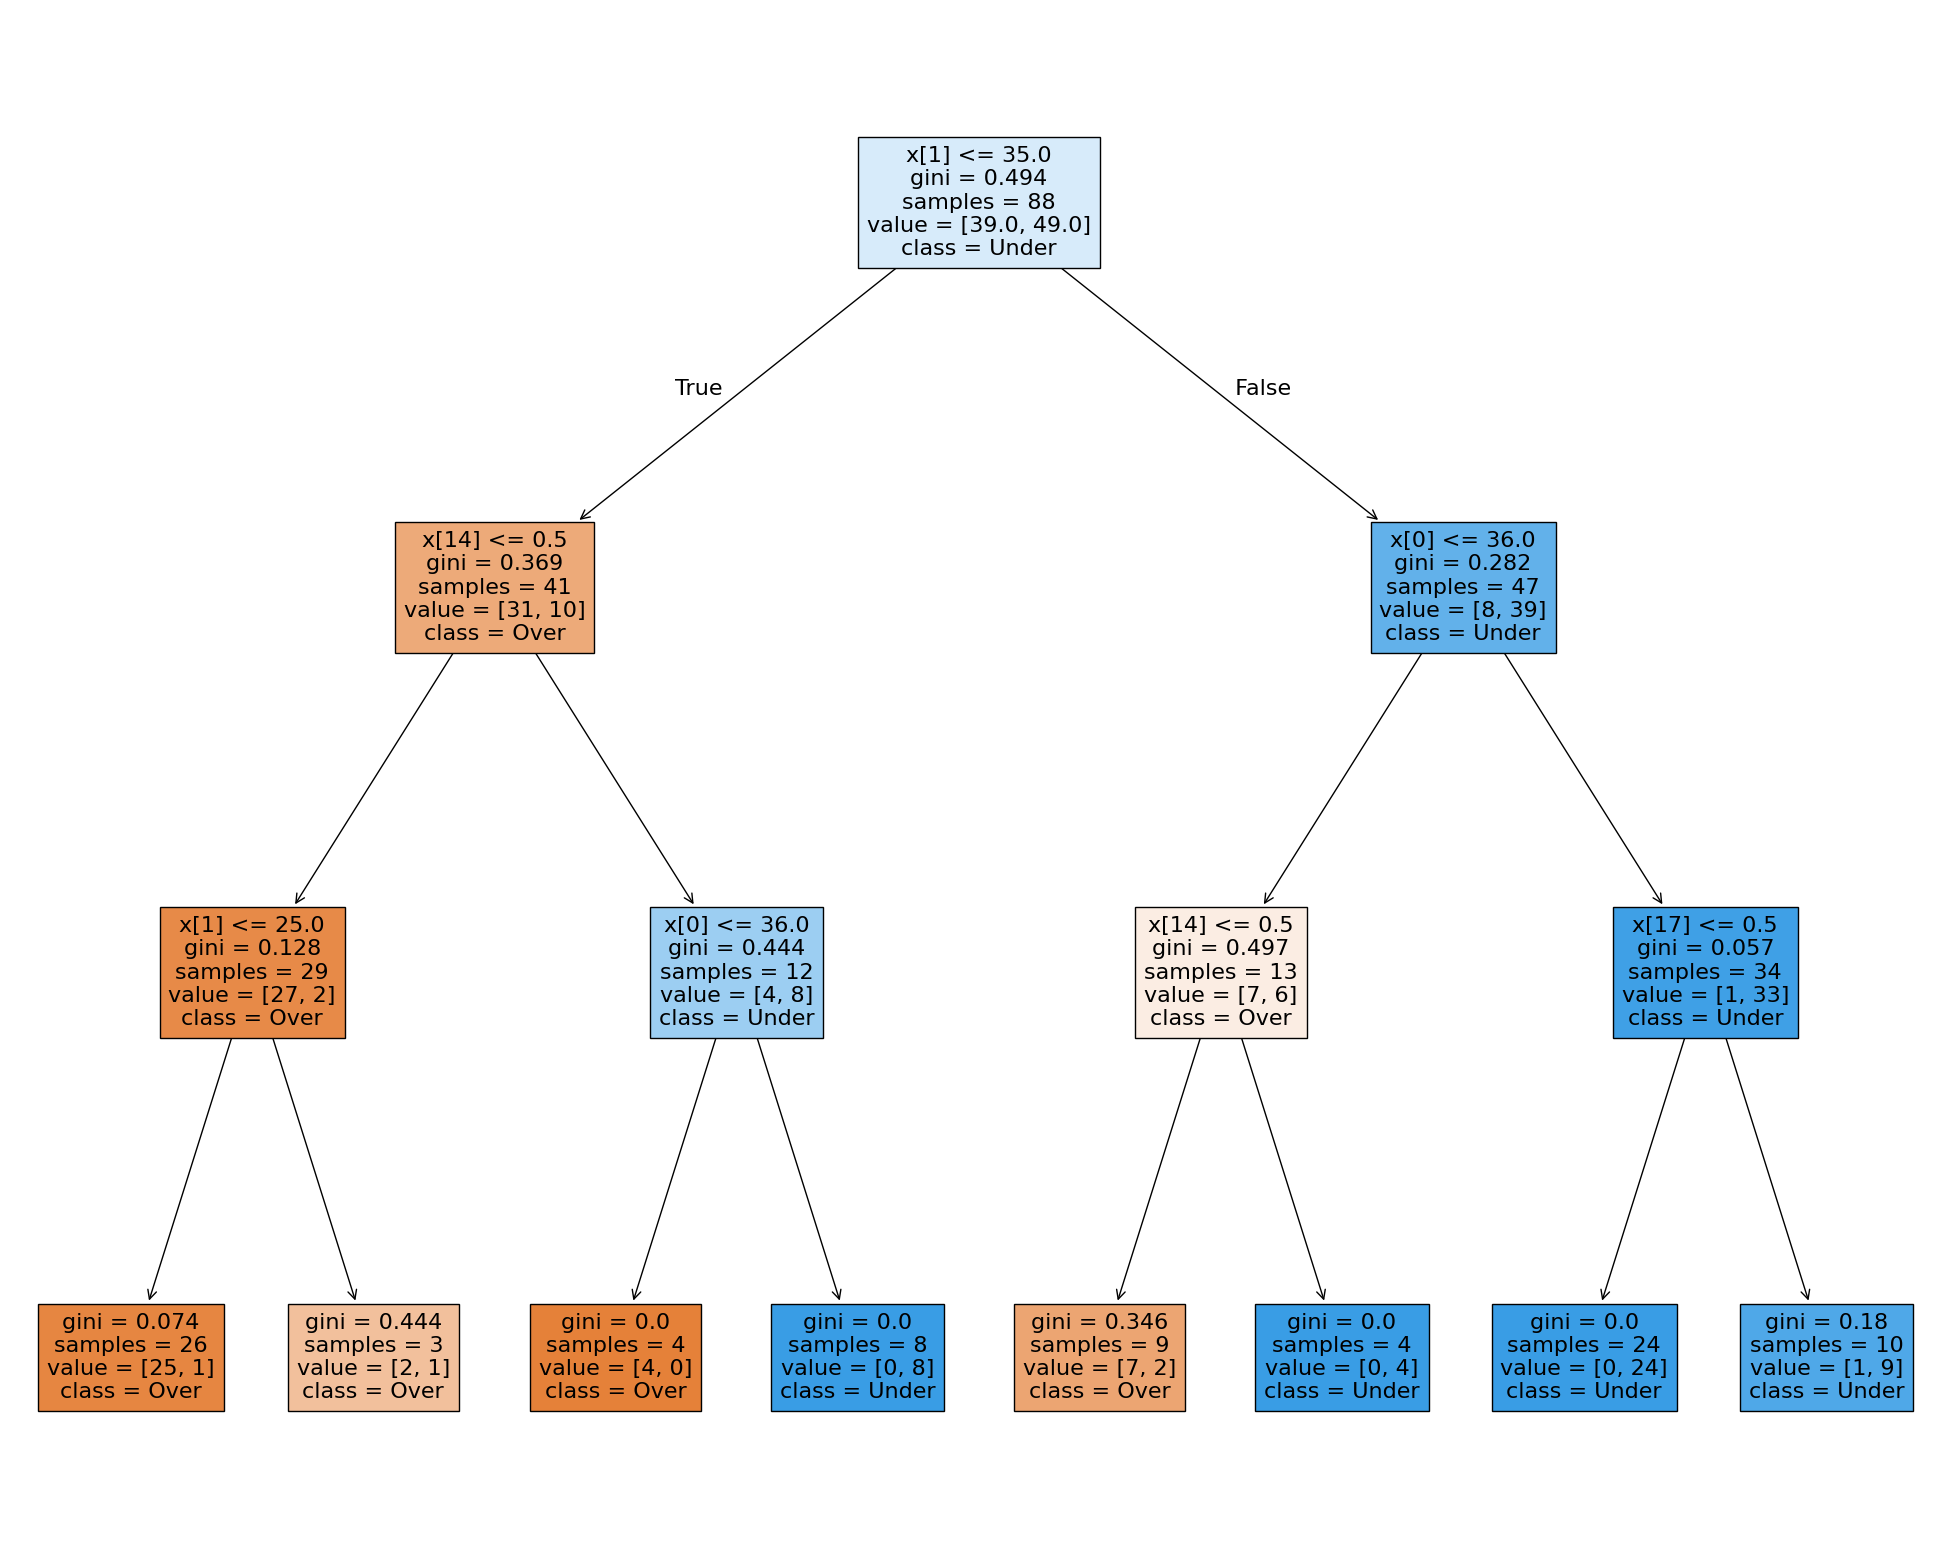

In [21]:
dtc = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_leaf=1, min_samples_split=2, random_state=2, splitter='best')
dtc.fit(X_lut, y01_lut)

fig = plt.figure(figsize=(25,20))
_ = plot_tree(dtc, class_names=['Over', 'Under'], filled=True)

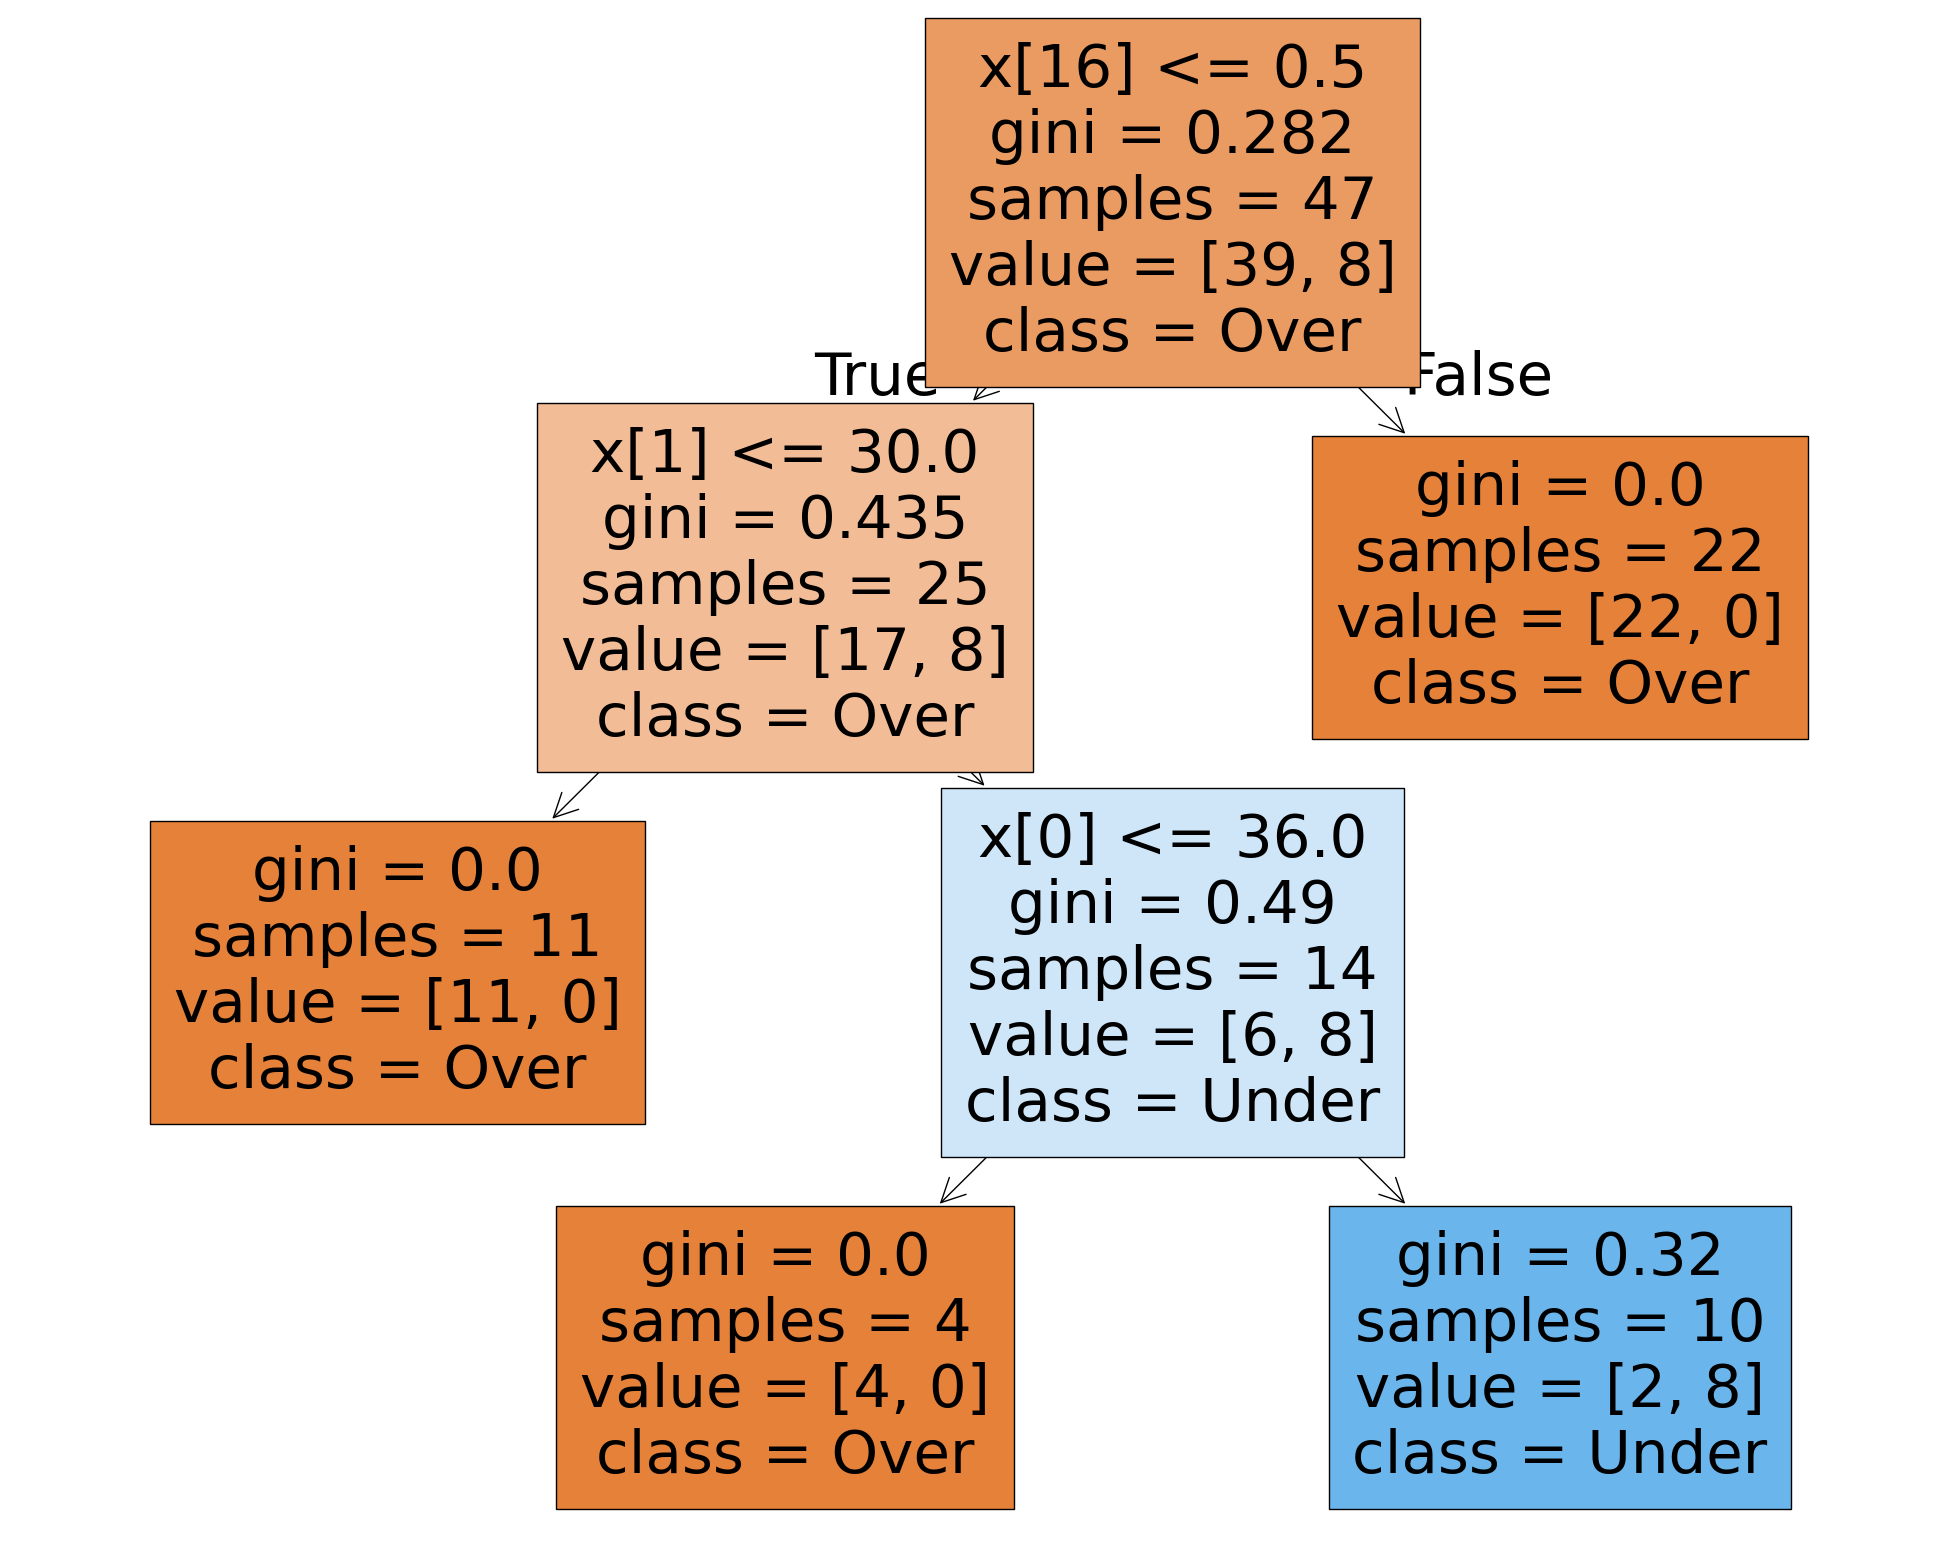

In [22]:
dtc = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_leaf=1, min_samples_split=2, random_state=2, splitter='best')
dtc.fit(X_myr, y01_myr)

fig = plt.figure(figsize=(25,20))
_ = plot_tree(dtc, class_names=['Over', 'Under'], filled=True)

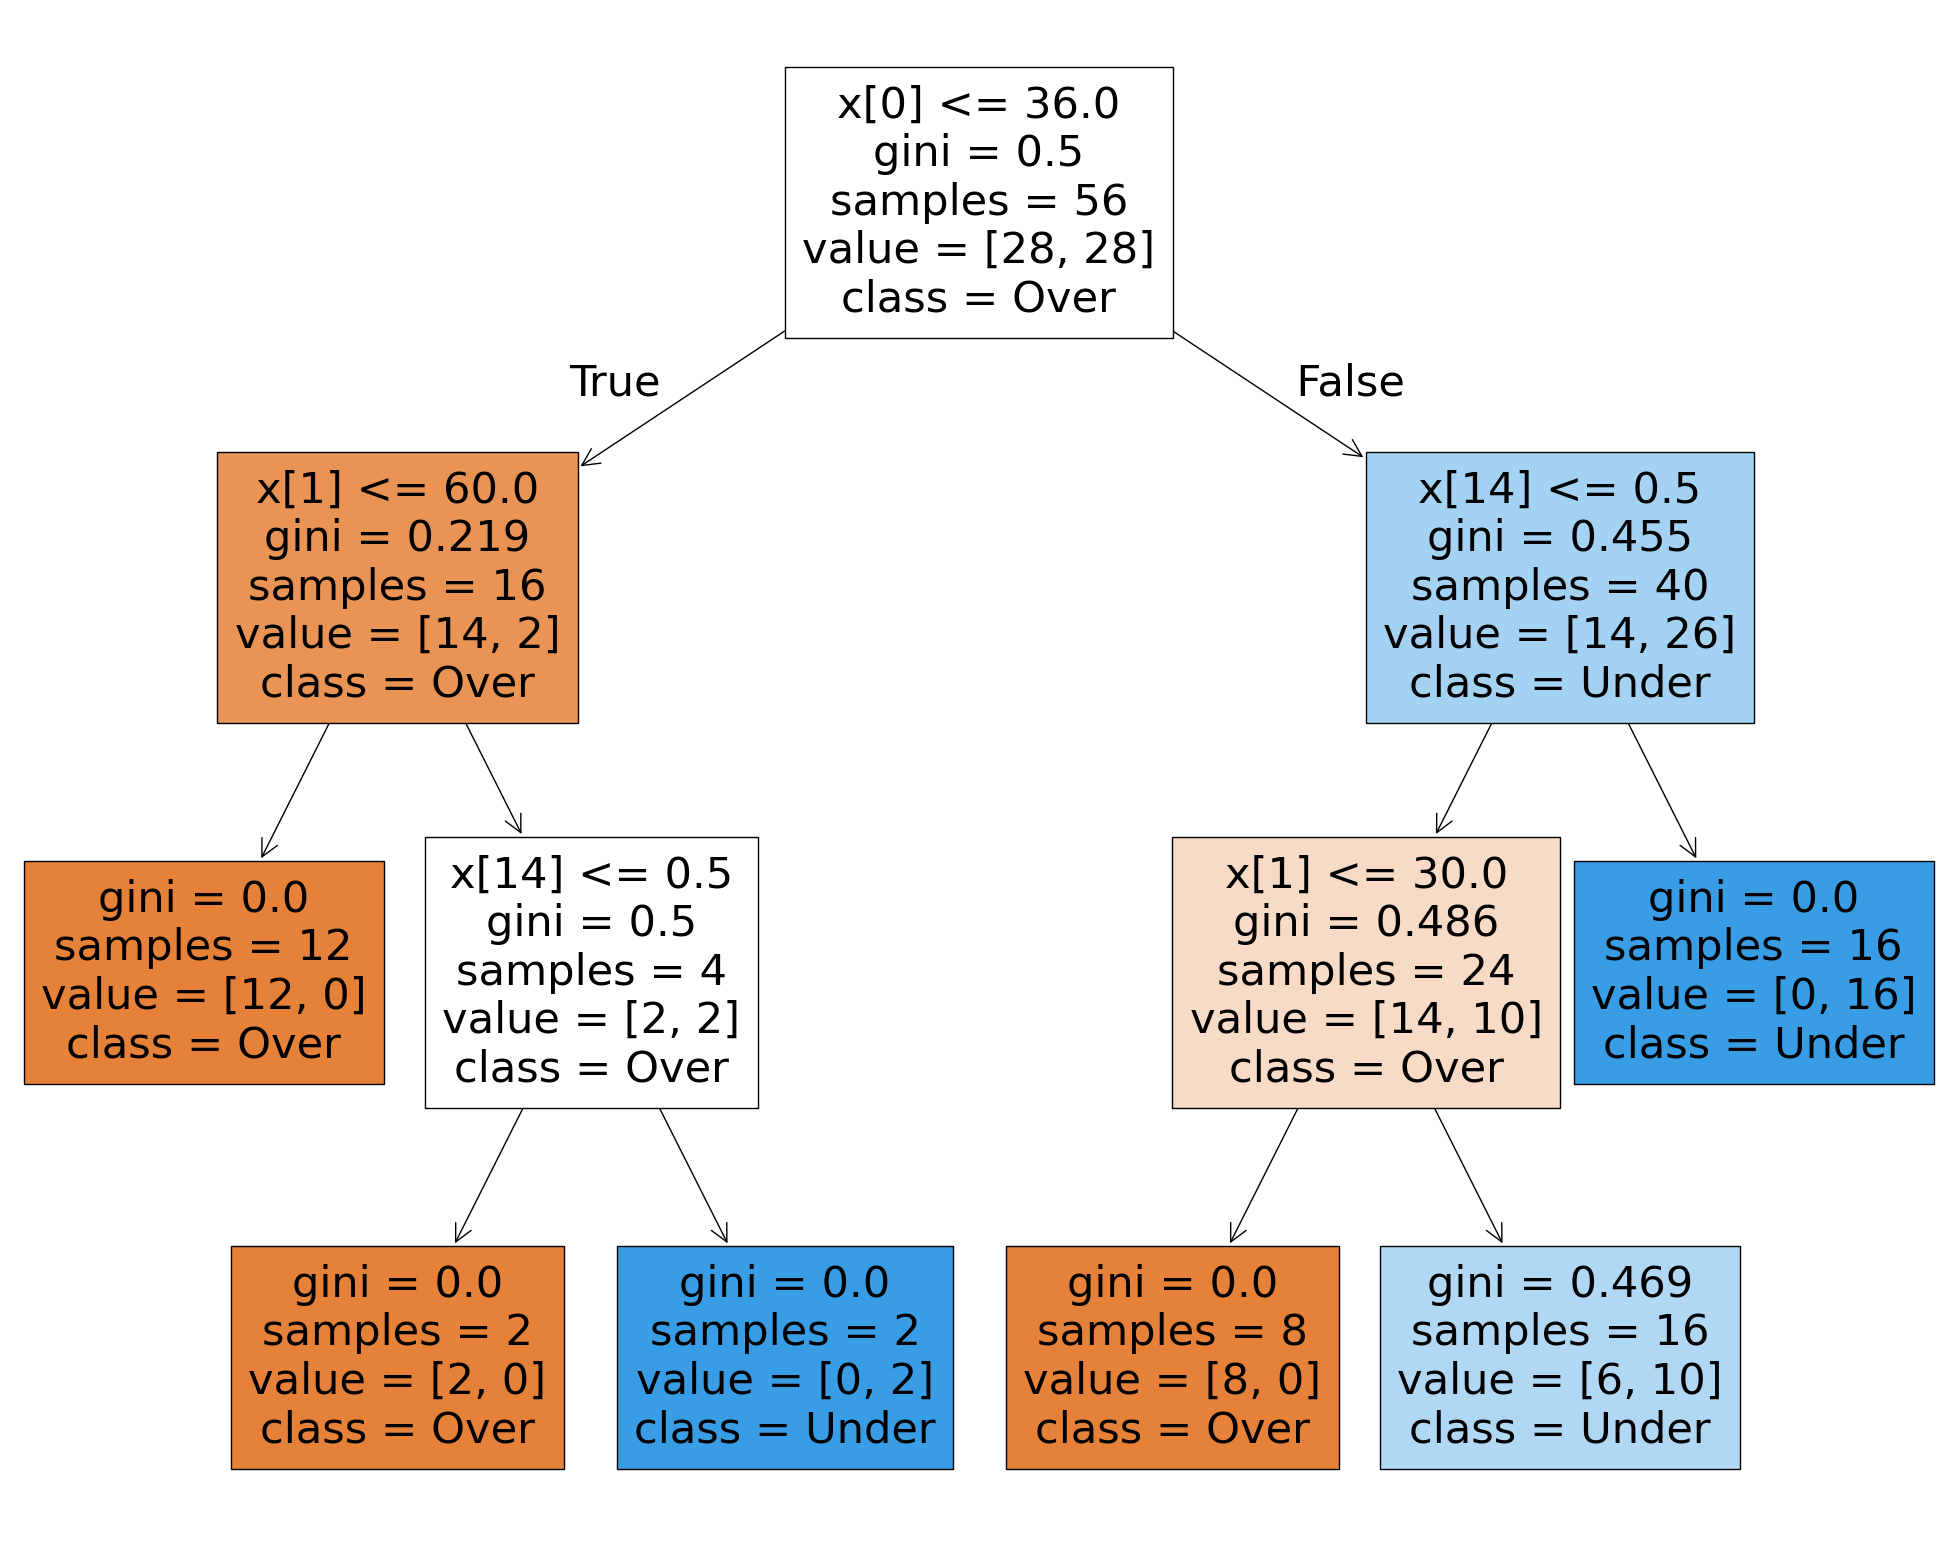

In [23]:
dtc = DecisionTreeClassifier(criterion='gini', max_depth=3, min_samples_leaf=1, min_samples_split=2, random_state=2, splitter='best')
dtc.fit(X_que, y01_que)

fig = plt.figure(figsize=(25,20))
_ = plot_tree(dtc, class_names=['Over', 'Under'], filled=True)